In [13]:
from veripulse.pulse import PulseConfig, PulseResult
import re
import json
import numpy as np
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

In [14]:
# data folder
data_dir = Path.cwd().parent/"data"

# file naming pattern
_PATTERN = re.compile(
    r"^(?P<method>[^_]+)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-(?P<identification>.+)\.json$"
)

# GRAPE_AVG:  GRAPE_AVG_pN_detX.XX_errX.XX-lamX.X-ID.json
_PATTERN_AVG = re.compile(
    r"^(?P<method>GRAPE_AVG)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-lam(?P<lam>[\d.]+)-(?P<identification>.+)\.json$"
)

# parsers

def parse_filename(path: Path) -> Optional[dict]:
    # Try GRAPE_AVG first (more specific), then fall back to generic
    m = _PATTERN_AVG.match(path.name) or _PATTERN.match(path.name)
    if not m:
        return None
    d = {
        "path":           path,
        "method":         m.group("method"),
        "num_tslots":     int(m.group("num_tslots")),
        "detuning":       float(m.group("detuning")),
        "drive_error":    float(m.group("drive_error")),
        "identification": m.group("identification"),
        "lam":            float(m.group("lam")) if "lam" in m.groupdict() and m.group("lam") is not None else None,
    }
    return d

def collect_files(
    directory: str | Path,
    method: Optional[str] = None,
    num_tslots: Optional[int] = None,
    detuning: Optional[float] = None,
    drive_error: Optional[float] = None,
    identification: Optional[str] = None,
    lam: Optional[float] = None,
    load: bool = False,
) -> list[dict]:
    results = []
    for path in sorted(Path(directory).glob("*.json")):
        meta = parse_filename(path)
        if meta is None:
            continue

        if method        is not None and meta["method"]      != method:                               continue
        if num_tslots    is not None and meta["num_tslots"]  != num_tslots:                           continue
        if detuning      is not None and f"{meta['detuning']:.2f}"    != f"{detuning:.2f}":           continue
        if drive_error   is not None and f"{meta['drive_error']:.2f}" != f"{drive_error:.2f}":        continue
        if identification is not None and meta["identification"] != str(identification):               continue
        if lam           is not None and (meta["lam"] is None or f"{meta['lam']:.3f}" != f"{lam:.3f}"): continue

        if load:
            with open(path) as f:
                meta["data"] = json.load(f)

        results.append(meta)

    return results

def summary_byslot(method, slots):
    summary = dict()
    for slot in slots: 
        summary[slot] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[], 'config':[]}
        runs = collect_files(data_dir, method=method, num_tslots=slot)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[slot]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[slot]['cost'].append(np.mean(res.err_hs_list)) 
            summary[slot]['si_lb'].append(res.si_lb)
            summary[slot]['si'].append(res.si)
            summary[slot]['diff'].append(res.si_lb - res.si)
            summary[slot]['config'].append(res.config)
            if method != 'GRAPE_AVG':
                # sum for all states 
                summary[slot]['eval'].append(sum(res.fid_compute_list))
            else : 
                summary[slot]['eval'].append(res.fid_compute_list)
    return summary




def plot_summary_property(
    summaries: dict,
    quantity: str,
    log_y: bool = False,
):
    fig, ax = plt.subplots(figsize=(6, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))

        means, stds = [], []
        for x in xs:
            vals = np.array(summary[x][quantity], dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())

        means = np.array(means)
        stds  = np.array(stds)

        line, = ax.plot(xs, means, lw=2.5, label=label)
        c = line.get_color()
        ax.fill_between(xs, means - stds, means + stds, alpha=0.18, color=c)

    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("x key")
    ax.set_ylabel(quantity)
    ax.set_title(quantity)
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.2, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_summary_properties_extremes(
    summaries: dict,
    main_quantity: str,
    main_case: str = "min",
    other_quantities: list = None,
    log_y: bool = False,
    resolution: bool = False,
):
    """
    Find the sample that achieves the extreme of `main_quantity`,
    then plot that sample's values for `main_quantity` and `other_quantities`.

    Parameters
    ----------
    summaries : dict
        {method_label: {x: {quantity: [values_per_sample, ...], ...}, ...}}
    main_quantity : str
        The quantity used to select the extreme sample (e.g. 'fid_ul').
    main_case : str
        'min' or 'max' — which extreme to pick for main_quantity.
    other_quantities : list of str, optional
        Additional quantities to plot from the same extreme sample.
    log_y : bool
        Use log scale on y-axis.
    resolution : bool
        If True, x-axis shows pulse resolution from config.
    """
    if other_quantities is None:
        other_quantities = []

    all_quantities = [main_quantity] + other_quantities
    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}

    fig, ax = plt.subplots(figsize=(7, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))
        if resolution:
            xs_plot = np.array([summary[x]['config'][0].evo_time / x for x in xs])
        else:
            xs_plot = xs
        c = method_colors[label]

        # For each x, find the sample index that achieves the extreme of main_quantity
        best_indices = []
        for x in xs:
            main_vals = np.array(summary[x][main_quantity], dtype=float)
            if main_case == "min":
                best_indices.append(np.argmin(main_vals))
            else:
                best_indices.append(np.argmax(main_vals))

        # Plot each quantity using the values from the selected sample
        for q, ls in zip(all_quantities, STYLES):
            ys = np.array([
                float(np.array(summary[x][q], dtype=float)[idx])
                for x, idx in zip(xs, best_indices)
            ])
            suffix = f"(from {main_case} {main_quantity})" if q != main_quantity else f"({main_case})"
            ax.plot(xs_plot, ys, lw=2, ls=ls, color=c, marker='o',
                    label=f"{label} — {q} {suffix}")

    if log_y:
        ax.set_yscale('log')
    if resolution:
        ax.set_xlabel("Pulse resolution (ns)")
        all_xs = sorted(set(
            summary[x]['config'][0].evo_time / x
            for summary in summaries.values()
            for x in summary.keys()
        ))
        ax.set_xticks(all_xs)
        ax.set_xticklabels([f"{v*1e9:.2f}" for v in all_xs], rotation=45)
    else:
        ax.set_xlabel("Number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left',
              borderaxespad=0.1)
    ax.grid(True, linewidth=0.2, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()

def plot_summary_properties(
    summaries: dict,
    quantities: list,
    log_y: bool = False,
    smearing: list = None,
    resolution: bool = False,
):
    if smearing is None:
        smearing = [True] * len(quantities)
    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}
    fig, ax = plt.subplots(figsize=(7, 3))
    for quantity, ls, smear in zip(quantities, STYLES, smearing):
        for label, summary in summaries.items():
            xs = np.array(sorted(summary.keys()))
            if resolution:
                xs_plot = np.array([summary[x]['config'][0].evo_time / x for x in xs])
            else:
                xs_plot = xs
            means, mins, maxs = [], [], []
            for x in xs:
                vals = np.array(summary[x][quantity], dtype=float)
                means.append(vals.mean())
                mins.append(vals.min())
                maxs.append(vals.max())
            means = np.array(means)
            mins = np.array(mins)
            maxs = np.array(maxs)
            c = method_colors[label]
            ax.plot(xs_plot, means, lw=2, ls=ls, color=c, label=f"{label} — {quantity}")
            if smear:
                ax.fill_between(xs_plot, mins, maxs, alpha=0.12, color=c)
    if log_y:
        ax.set_yscale('log')
    if resolution:
        ax.set_xlabel("Pulse resolution (ns)")
        # Collect all unique x values and set ticks at each one
        all_xs = sorted(set(
            cfg.evo_time / x
            for summary in summaries.values()
            for x in summary.keys()
            for cfg in [summary[x]['config'][0]]
        ))
        ax.set_xticks(all_xs)
        ax.set_xticklabels([f"{v*1e9:.2f}" for v in all_xs], rotation=45)
    else:
        ax.set_xlabel("Number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=.3)
    ax.grid(True, linewidth=0.3, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()

def plot_fid_spread_from_extreme_si(
    data_dir,
    methods,
    slots,
    si_case="min",
    log_y=False,
    resolution=False,
):
    """
    For each method and number of pulses, find the sample with the
    extreme SI, then plot mean (min–max) of that sample's err_ul_list
    on the left axis, and SI on the right axis (dashed).

    Parameters
    ----------
    data_dir : str
        Directory containing result files.
    methods : list of str
        Method names for collect_files (e.g. ['GRAPE_AVG', 'CRAB']).
    slots : list
        List of tslots values.
    log_y : bool
        Use log scale on y-axis.
    resolution : bool
        If True, x-axis shows pulse resolution from config.
    """
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    MARKERS = ['X', 'o', '^', 'D', 'v', 'P', '*', 'X']

    fig, ax = plt.subplots(figsize=(8, 5))
    ax2 = ax.twinx()

    n = len(methods)

    for m_idx, method in enumerate(methods):
        xs = []
        ys_mean = []
        ys_err_low = []
        ys_err_high = []
        si_vals_plot = []

        for slot in slots:
            runs = collect_files(data_dir, method=method, num_tslots=slot)
            if not runs:
                continue

            results = [PulseResult.load(r['path']) for r in runs]
            si_vals = np.array([res.si for res in results])

            best_idx = np.argmin(si_vals) if si_case == "min" else np.argmax(si_vals)
            err_ul = np.array(results[best_idx].err_ul_list, dtype=float)

            if len(err_ul) == 0:
                continue

            if resolution:
                evo_time = results[0].config.evo_time
                xs.append(evo_time / slot)
            else:
                xs.append(slot)
            mean_val = np.mean(err_ul)
            ys_mean.append(mean_val)
            ys_err_low.append(mean_val - np.min(err_ul))
            ys_err_high.append(np.max(err_ul) - mean_val)
            si_vals_plot.append(si_vals[best_idx])

        c = COLORS[m_idx]
        mk = MARKERS[m_idx % len(MARKERS)]

        # err_ul on left axis (solid)
        ax.errorbar(xs, ys_mean, yerr=[ys_err_low, ys_err_high],
                    lw=2, capsize=4, capthick=1.5, alpha=0.8,
                    color=c, marker=mk,
                    markersize=8, label=f"{method} — err_ul", zorder=n - m_idx + 2)

        # SI on right axis (dashed)
        ax2.plot(xs, si_vals_plot, lw=2, ls='--', color=c, marker=mk,
                 markersize=6, alpha=0.8, label=f"{method} — SI")

    # Make sure ax2 is visible
    ax2.set_zorder(ax.get_zorder() + 1)
    ax.patch.set_visible(False)

    if log_y:
        ax.set_yscale('log')
        ax2.set_yscale('log')

    if resolution:
        ax.set_xlabel("Pulse resolution (ns)")
        all_xs = sorted(set(x for x in ax.get_xticks()))
        # Collect all x values from plotted data
        all_plot_xs = sorted(set(
            x for line in ax.get_lines() for x in line.get_xdata()
        ))
        if all_plot_xs:
            ax.set_xticks(all_plot_xs)
            ax.set_xticklabels([f"{v*1e9:.2f}" for v in all_plot_xs], rotation=45)
    else:
        ax.set_xlabel("Number of pulses")
    ax.set_ylabel("1-F (mean, min–max range)")
    ax2.set_ylabel("SI (dashed)")
    ax.set_title(f"err_ul & SI from {si_case} SI sample")

    # Combine legends from both axes
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, bbox_to_anchor=(1.15, 1),
              loc='upper left', borderaxespad=0.1)

    ax.grid(True, linewidth=0.2, alpha=0.9)
    ax.spines[["top", "right"]].set_visible(True)
    fig.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.show()

def plot_grape_heatmap(data_dir, lambdas, tslots_list, show='si', resolution=False):
    """
    Heatmap of mean values from GRAPE optimisation runs.

    Parameters
    ----------
    data_dir : str
        Directory containing the GRAPE result files.
    lambdas : list
        List of lambda values used.
    tslots_list : list
        List of tslots values used.
    show : str
        'si' to plot SI values, 'fid' to plot mean of err_ul_list.
    resolution : bool
        If True, x-axis shows pulse resolution from config.
    """
    n_lam = len(lambdas)
    n_tslots = len(tslots_list)

    mean_si = np.full((n_lam, n_tslots), np.nan)
    std_si = np.full((n_lam, n_tslots), np.nan)
    evo_times = {}

    for i, lam in enumerate(lambdas):
        for j, tslots in enumerate(tslots_list):
            metas = collect_files(directory=data_dir, method='GRAPE_AVG', num_tslots=tslots, lam=lam)
            si_values = []
            for m in metas:
                res = PulseResult.load(m['path'])
                if show == 'si':
                    si_values.append(res.si)
                elif show == 'fid':
                    si_values.append(np.mean(res.err_ul_list))
                if tslots not in evo_times:
                    evo_times[tslots] = res.config.evo_time
            if si_values:
                mean_si[i, j] = np.mean(si_values)
                std_si[i, j] = np.std(si_values)

    fig, ax = plt.subplots(figsize=(max(6, n_tslots * 1.5), max(4, n_lam * 1.2)))

    vmin = np.nanmin(mean_si[mean_si > 0])
    vmax = np.nanmax(mean_si)
    im = ax.imshow(mean_si, aspect="auto", cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax))

    label = "Mean SI" if show == 'si' else "Mean 1-F"
    cbar = fig.colorbar(im, ax=ax, label=label)

    # Annotate each cell with mean ± std
    for i in range(n_lam):
        for j in range(n_tslots):
            if np.isnan(mean_si[i, j]):
                ax.text(j, i, "N/A", ha="center", va="center", color="gray")
            else:
                text = f"{mean_si[i, j]:.4f}\n±{std_si[i, j]:.4f}"
                # Pick text color for readability
                norm_val = (mean_si[i, j] - np.nanmin(mean_si)) / (np.nanmax(mean_si) - np.nanmin(mean_si) + 1e-12)
                color = "white" if norm_val < 0.5 else "black"
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)

    ax.set_xticks(range(n_tslots))
    if resolution:
        xlabels = [f"{evo_times.get(ts, 0) / ts * 1e9:.2f}" for ts in tslots_list]
        ax.set_xticklabels(xlabels, rotation=45)
        ax.set_xlabel("Pulse resolution (ns)")
    else:
        ax.set_xticklabels(tslots_list)
        ax.set_xlabel("tslots")
    ax.set_yticks(range(n_lam))
    ax.set_yticklabels([f"{l:.2g}" for l in lambdas])
    ax.set_ylabel("λ")
    ax.set_title(f"GRAPE Optimisation: {label}")

    fig.tight_layout()
    plt.show()

In [29]:
slots = [30, 40, 50, 60, 70, 80, 100, 120]
summaries = dict()
summaries['GRAPE'] = summary_byslot("GRAPE", slots)
#summaries['CRAB'] = summary_byslot('CRAB', slots)
summaries['GRAPE_AVG'] = summary_byslot('GRAPE_AVG', slots)

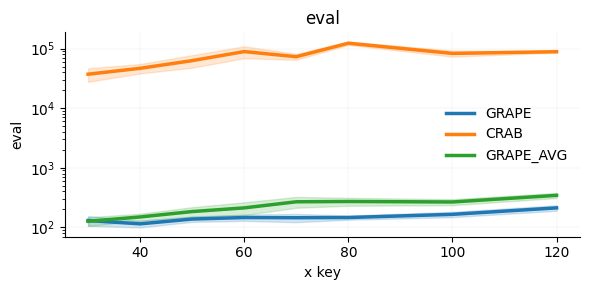

In [16]:
plot_summary_property(summaries = summaries, quantity='eval', log_y=True)

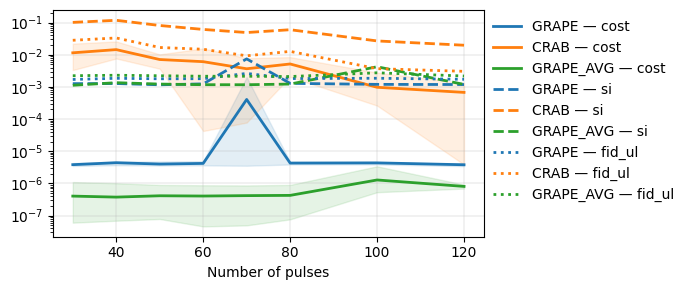

In [25]:
plot_summary_properties(
    summaries=summaries,
    quantities=['cost','si','fid_ul'],
    log_y=True,
    smearing = [True, False, False],
    resolution = False
)

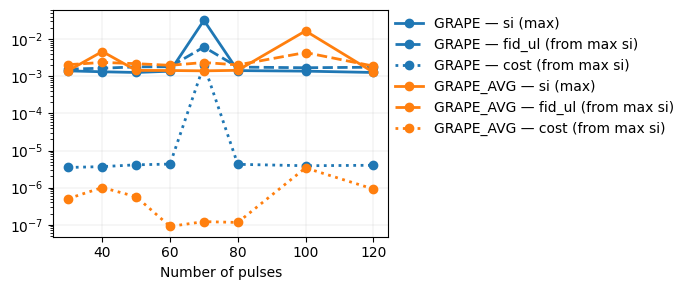

In [32]:
plot_summary_properties_extremes(
    summaries=summaries,
    main_quantity='si',
    main_case='max',
    other_quantities=['fid_ul','cost'],
    log_y=True,
    resolution=False
)

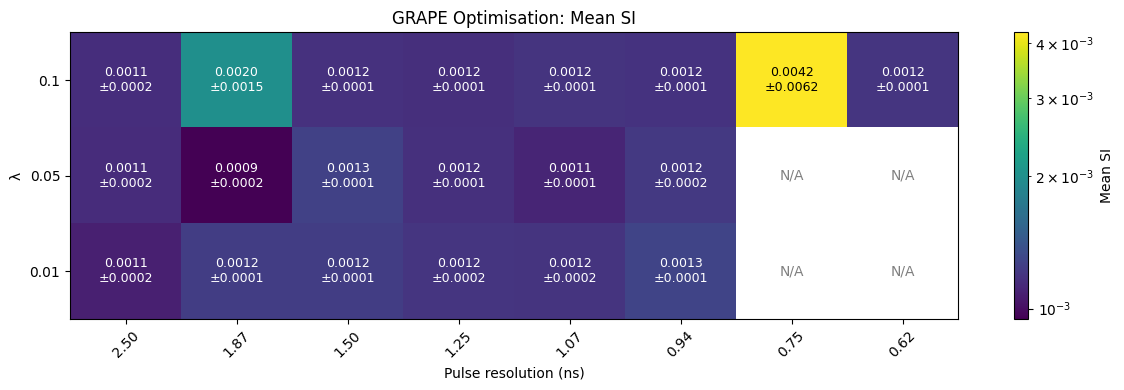

In [31]:
lambdas = [0.1, 0.05, 0.01]
plot_grape_heatmap(data_dir, lambdas, slots, show='si', resolution=True)

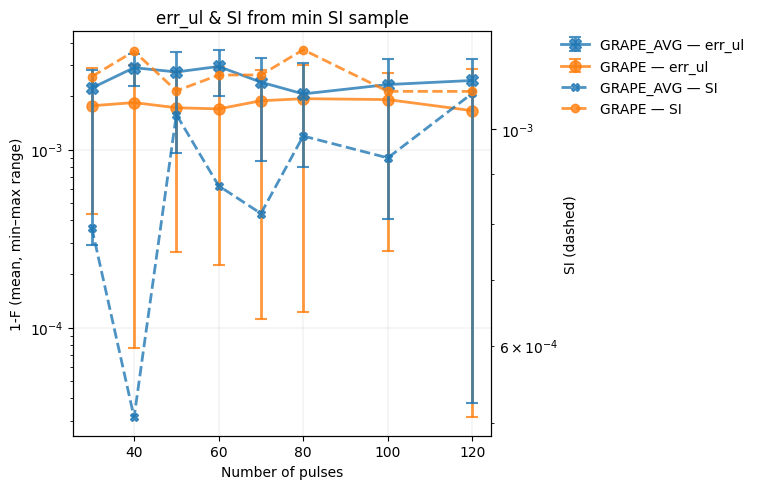

In [34]:
plot_fid_spread_from_extreme_si(data_dir, methods=['GRAPE_AVG','GRAPE'], slots=slots, si_case='min', log_y=True, resolution=False)